Device: cpu
Размер: (4320, 2)
Даты: 2025-01-01 00:00:00 — 2025-06-29 23:00:00
Пропуски:
date      0
target    0
dtype: int64


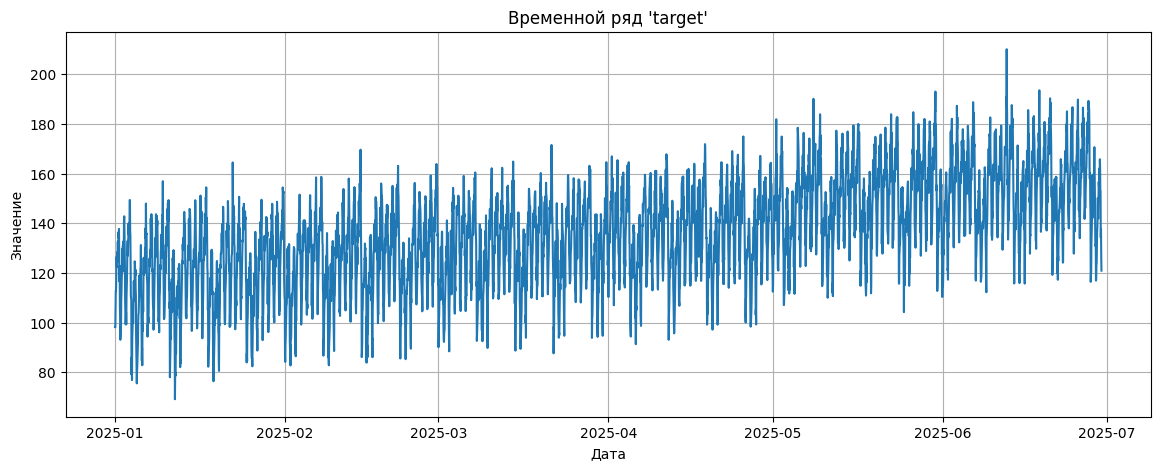

Train: 2025-01-01 00:00:00 → 2025-05-06 23:00:00 | 3024 строк
Val:   2025-05-07 00:00:00 → 2025-06-02 23:00:00 | 648 строк
Test:  2025-06-03 00:00:00 → 2025-06-29 23:00:00 | 648 строк


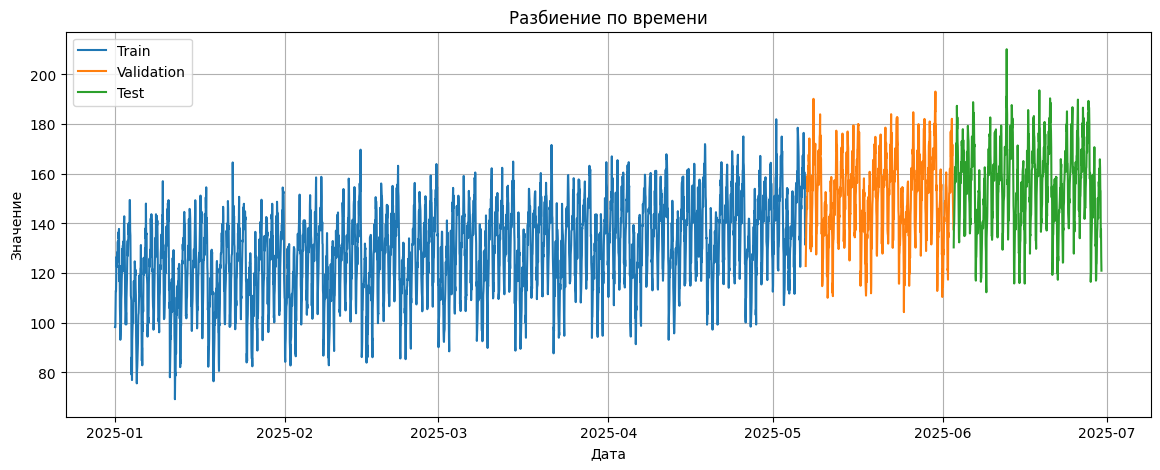

B1, B2, B3 выполнены.
Начало обучения GRU...
Epoch 20: train_loss=0.0997, val_loss=0.1591
Early stopping at epoch 38
Обучение GRU завершено.
runs.csv сохранен.
Модель GRU сохранена.


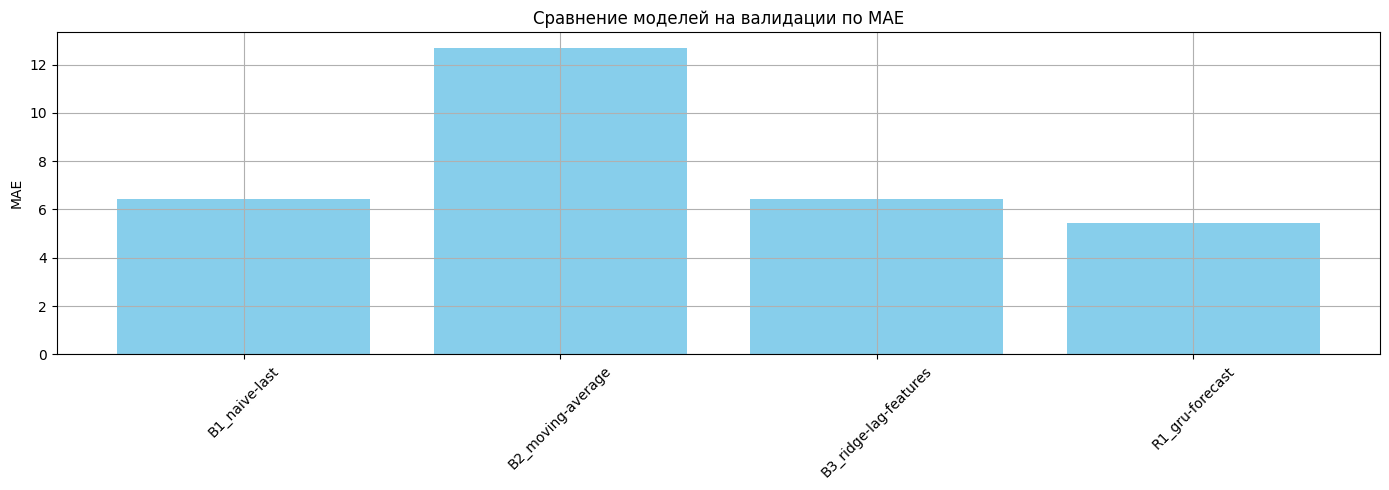

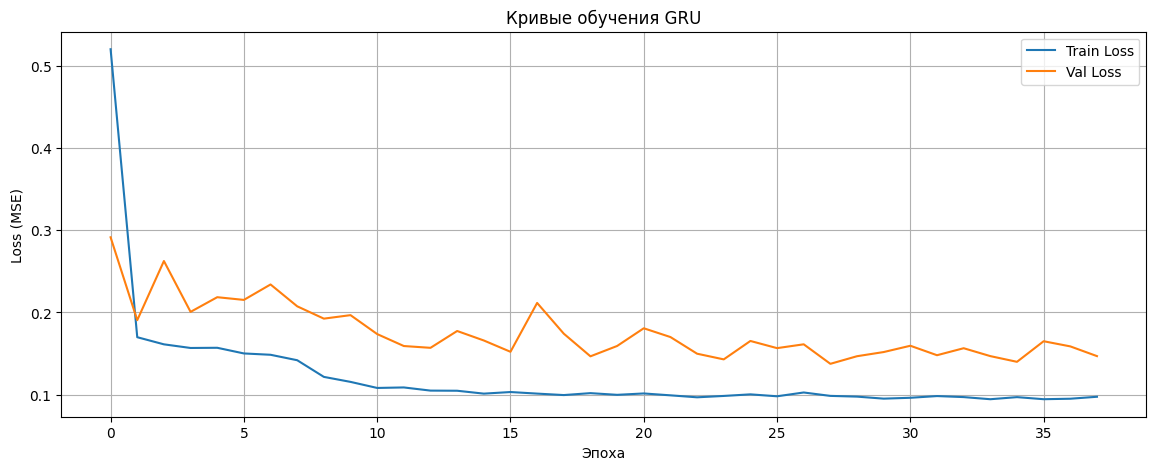

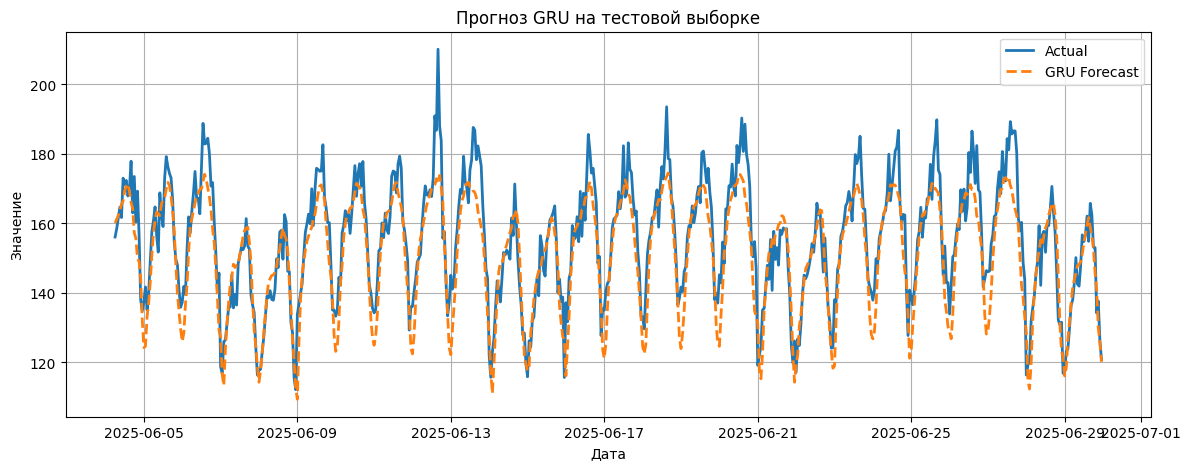


ФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ
                   model        MAE       RMSE      MAPE   test_MAE  test_RMSE  test_MAPE
0          B1_naive-last   6.444815   8.201023  4.397922   6.342438   8.059069   4.148548
1      B2_moving-average  12.702013  15.217645  8.816864  12.740309  15.238699   8.549006
2  B3_ridge-lag-features   6.445173   7.947282  4.309216   5.431345   6.939907   3.531630
3        R1_gru-forecast   5.456699   7.080919  3.660216   6.456124   8.258029   4.145394

Лучшая модель по val_MAE: R1_gru-forecast
Её test_MAE: 6.456124208320692

✅ Все артефакты сохранены в папку 'artifacts/'


In [9]:
# ============================================
# HW12 - Полный код (все в одной ячейке)
# ============================================

import os
import random
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim

from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

# ========== 1. Настройки ==========
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

SEED = 42
set_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Создаем папки для артефактов
os.makedirs("artifacts/figures", exist_ok=True)
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.grid"] = True

# ========== 2. Загрузка данных ==========
df = pd.read_csv("../datasets/S12-hw-dataset.csv")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

# Определяем целевую колонку
TARGET_COL = "target"
if TARGET_COL not in df.columns:
    numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
    if len(numeric_cols) >= 1:
        TARGET_COL = numeric_cols[0]
        print(f"Целевая колонка: {TARGET_COL}")
    else:
        raise ValueError("Не могу определить целевую колонку")

print(f"Размер: {df.shape}")
print(f"Даты: {df['date'].min()} — {df['date'].max()}")
print(f"Пропуски:\n{df.isnull().sum()}")

# График
plt.figure()
plt.plot(df["date"], df[TARGET_COL], lw=1.5)
plt.title(f"Временной ряд '{TARGET_COL}'")
plt.xlabel("Дата")
plt.ylabel("Значение")
plt.savefig("artifacts/figures/series_initial.png")
plt.show()

# ========== 3. Temporal split ==========
TRAIN_RATIO = 0.7
VAL_RATIO = 0.15

n = len(df)
train_end = int(n * TRAIN_RATIO)
val_end = int(n * (TRAIN_RATIO + VAL_RATIO))

train_df = df.iloc[:train_end].copy()
val_df = df.iloc[train_end:val_end].copy()
test_df = df.iloc[val_end:].copy()

print(f"Train: {train_df['date'].min()} → {train_df['date'].max()} | {len(train_df)} строк")
print(f"Val:   {val_df['date'].min()} → {val_df['date'].max()} | {len(val_df)} строк")
print(f"Test:  {test_df['date'].min()} → {test_df['date'].max()} | {len(test_df)} строк")

plt.figure()
plt.plot(train_df["date"], train_df[TARGET_COL], label="Train")
plt.plot(val_df["date"], val_df[TARGET_COL], label="Validation")
plt.plot(test_df["date"], test_df[TARGET_COL], label="Test")
plt.title("Разбиение по времени")
plt.xlabel("Дата")
plt.ylabel("Значение")
plt.legend()
plt.savefig("artifacts/figures/series_split.png")
plt.show()

# ========== 4. Признаки для baseline ==========
def add_calendar_features(df):
    out = df.copy()
    out["dayofweek"] = out["date"].dt.dayofweek
    out["month"] = out["date"].dt.month
    out["dow_sin"] = np.sin(2 * np.pi * out["dayofweek"] / 7)
    out["dow_cos"] = np.cos(2 * np.pi * out["dayofweek"] / 7)
    out["month_sin"] = np.sin(2 * np.pi * out["month"] / 12)
    out["month_cos"] = np.cos(2 * np.pi * out["month"] / 12)
    return out

def add_lag_rolling_features(df, target_col):
    out = df.copy()
    for lag in [1, 7, 14]:
        out[f"lag_{lag}"] = out[target_col].shift(lag)
    out["rolling_mean_7"] = out[target_col].shift(1).rolling(window=7).mean()
    out["rolling_std_7"] = out[target_col].shift(1).rolling(window=7).std()
    return out

feat_df = add_calendar_features(df)
feat_df = add_lag_rolling_features(feat_df, TARGET_COL)
feat_df = feat_df.dropna().reset_index(drop=True)

train_feat = feat_df[feat_df["date"] < val_df["date"].min()].copy()
val_feat = feat_df[(feat_df["date"] >= val_df["date"].min()) & (feat_df["date"] < test_df["date"].min())].copy()
test_feat = feat_df[feat_df["date"] >= test_df["date"].min()].copy()

feature_cols = ["dayofweek", "month", "dow_sin", "dow_cos", "month_sin", "month_cos",
                "lag_1", "lag_7", "lag_14", "rolling_mean_7", "rolling_std_7"]

X_train = train_feat[feature_cols]
y_train = train_feat[TARGET_COL]
X_val = val_feat[feature_cols]
y_val = val_feat[TARGET_COL]
X_test = test_feat[feature_cols]
y_test = test_feat[TARGET_COL]

# ========== 5. Метрики и B1, B2, B3 ==========
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def mape(y_true, y_pred, eps=1e-8):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), eps))) * 100

def evaluate(y_true, y_pred, model_name):
    return {
        "model": model_name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
        "MAPE": mape(y_true, y_pred)
    }

# B1: Naive Last
val_pred_b1 = val_feat["lag_1"].to_numpy()
test_pred_b1 = test_feat["lag_1"].to_numpy()
res_b1 = evaluate(y_val, val_pred_b1, "B1_naive-last")
res_b1_test = evaluate(y_test, test_pred_b1, "B1_naive-last")

# B2: Moving Average
val_pred_b2 = val_feat["rolling_mean_7"].to_numpy()
test_pred_b2 = test_feat["rolling_mean_7"].to_numpy()
res_b2 = evaluate(y_val, val_pred_b2, "B2_moving-average")
res_b2_test = evaluate(y_test, test_pred_b2, "B2_moving-average")

# B3: Ridge
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

val_pred_b3 = ridge.predict(X_val_scaled)
test_pred_b3 = ridge.predict(X_test_scaled)
res_b3 = evaluate(y_val, val_pred_b3, "B3_ridge-lag-features")
res_b3_test = evaluate(y_test, test_pred_b3, "B3_ridge-lag-features")

print("B1, B2, B3 выполнены.")

# ========== 6. GRU Dataset ==========
WINDOW_SIZE = 30
BATCH_SIZE = 64

scaler_gru = StandardScaler()
train_scaled = scaler_gru.fit_transform(train_df[[TARGET_COL]].values).flatten()
val_scaled = scaler_gru.transform(val_df[[TARGET_COL]].values).flatten()
test_scaled = scaler_gru.transform(test_df[[TARGET_COL]].values).flatten()

def create_sequences(data, window_size):
    xs, ys = [], []
    for i in range(len(data) - window_size):
        xs.append(data[i:i+window_size])
        ys.append(data[i+window_size])
    return np.array(xs), np.array(ys)

X_train_seq, y_train_seq = create_sequences(train_scaled, WINDOW_SIZE)
X_val_seq, y_val_seq = create_sequences(val_scaled, WINDOW_SIZE)
X_test_seq, y_test_seq = create_sequences(test_scaled, WINDOW_SIZE)

class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = TimeSeriesDataset(X_train_seq, y_train_seq)
val_ds = TimeSeriesDataset(X_val_seq, y_val_seq)
test_ds = TimeSeriesDataset(X_test_seq, y_test_seq)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

# ========== 7. Модель GRU и обучение ==========
class GRUForecaster(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, output_size=1, dropout=0.2):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_size, output_size)
    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        out, _ = self.gru(x, h0)
        return self.fc(out[:, -1, :]).squeeze()

model = GRUForecaster().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

best_val_loss = float('inf')
best_state = None
patience = 10
no_improve = 0
train_losses, val_losses = [], []

print("Начало обучения GRU...")

for epoch in range(100):
    # Train
    model.train()
    epoch_loss = 0
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(Xb), yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * Xb.size(0)
    epoch_loss /= len(train_loader.dataset)
    train_losses.append(epoch_loss)
    
    # Val
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for Xb, yb in val_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            loss = criterion(model(Xb), yb)
            val_loss += loss.item() * Xb.size(0)
    val_loss /= len(val_loader.dataset)
    val_losses.append(val_loss)
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = model.state_dict().copy()
        no_improve = 0
    else:
        no_improve += 1
    
    if (epoch+1) % 20 == 0:
        print(f"Epoch {epoch+1}: train_loss={epoch_loss:.4f}, val_loss={val_loss:.4f}")
    
    if no_improve >= patience:
        print(f"Early stopping at epoch {epoch+1}")
        break

model.load_state_dict(best_state)
print("Обучение GRU завершено.")

# ========== 8. Оценка GRU ==========
# Валидация
model.eval()
val_preds_scaled = []
with torch.no_grad():
    for Xb, _ in val_loader:
        Xb = Xb.to(device)
        val_preds_scaled.extend(model(Xb).cpu().numpy())
val_preds = scaler_gru.inverse_transform(np.array(val_preds_scaled).reshape(-1, 1)).flatten()
y_val_gru = scaler_gru.inverse_transform(y_val_seq.reshape(-1, 1)).flatten()

# Тест
test_preds_scaled = []
with torch.no_grad():
    for Xb, _ in test_loader:
        Xb = Xb.to(device)
        test_preds_scaled.extend(model(Xb).cpu().numpy())
test_preds = scaler_gru.inverse_transform(np.array(test_preds_scaled).reshape(-1, 1)).flatten()
y_test_gru = scaler_gru.inverse_transform(y_test_seq.reshape(-1, 1)).flatten()

res_r1 = evaluate(y_val_gru, val_preds, "R1_gru-forecast")
res_r1_test = evaluate(y_test_gru, test_preds, "R1_gru-forecast")

# ========== 9. Сбор результатов и сохранение ==========
all_results_val = [res_b1, res_b2, res_b3, res_r1]
test_results_map = {
    "B1_naive-last": res_b1_test,
    "B2_moving-average": res_b2_test,
    "B3_ridge-lag-features": res_b3_test,
    "R1_gru-forecast": res_r1_test
}

for res in all_results_val:
    test_res = test_results_map[res["model"]]
    res["test_MAE"] = test_res["MAE"]
    res["test_RMSE"] = test_res["RMSE"]
    res["test_MAPE"] = test_res["MAPE"]

runs_df = pd.DataFrame(all_results_val)
runs_df.to_csv("artifacts/runs.csv", index=False)
print("runs.csv сохранен.")

# Сохранение модели GRU
config = {
    "window_size": WINDOW_SIZE,
    "hidden_size": 64,
    "num_layers": 2,
    "dropout": 0.2,
    "learning_rate": 0.001,
    "batch_size": BATCH_SIZE,
    "seed": SEED,
    "scaler_mean": scaler_gru.mean_.tolist(),
    "scaler_scale": scaler_gru.scale_.tolist(),
    "best_val_loss": best_val_loss
}
torch.save(best_state, "artifacts/best_gru.pt")
with open("artifacts/best_gru_config.json", "w") as f:
    json.dump(config, f, indent=4)
print("Модель GRU сохранена.")

# ========== 10. Визуализации ==========
# Сравнение моделей
plt.figure()
models = [r["model"] for r in all_results_val]
mae_vals = [r["MAE"] for r in all_results_val]
plt.bar(models, mae_vals, color='skyblue')
plt.title("Сравнение моделей на валидации по MAE")
plt.ylabel("MAE")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("artifacts/figures/baselines_compare.png")
plt.show()

# Кривые обучения GRU
plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.title("Кривые обучения GRU")
plt.xlabel("Эпоха")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.savefig("artifacts/figures/gru_learning_curves.png")
plt.show()

# Финальный прогноз на тесте
plt.figure()
plt.plot(test_df["date"].values[WINDOW_SIZE:], y_test_gru, label="Actual", lw=2)
plt.plot(test_df["date"].values[WINDOW_SIZE:], test_preds, label="GRU Forecast", lw=2, linestyle='--')
plt.title("Прогноз GRU на тестовой выборке")
plt.xlabel("Дата")
plt.ylabel("Значение")
plt.legend()
plt.savefig("artifacts/figures/best_forecast_test.png")
plt.show()

# ========== 11. Вывод результатов ==========
print("\n" + "="*50)
print("ФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ")
print("="*50)
print(runs_df.to_string())
print("\n" + "="*50)
print("Лучшая модель по val_MAE:", runs_df.loc[runs_df["MAE"].idxmin(), "model"])
print("Её test_MAE:", runs_df.loc[runs_df["MAE"].idxmin(), "test_MAE"])
print("="*50)

print("\n✅ Все артефакты сохранены в папку 'artifacts/'")